In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from linearmodels import PanelOLS
from statsmodels.api import OLS
import statsmodels.api as sm

# Question 1 — TWFE & Event-Study

## a) TWFE

In [4]:
url = "https://raw.githubusercontent.com/LOST-STATS/LOST-STATS.github.io/master/Model_Estimation/Data/Event_Study_DiD/bacon_example.csv"
df = pd.read_csv(url)
print(df.head())
print(df.info())

   stfips  year    _nfd  post      asmrs         pcinc     asmrh     cases  \
0       1  1964  1971.0     0  35.639885  12406.178537  5.007341  0.012312   
1       1  1965  1971.0     0  41.543755  13070.206738  4.425367  0.010419   
2       1  1966  1971.0     0  34.252335  13526.663217  4.874819  0.009900   
3       1  1967  1971.0     0  34.465023  13918.189823  5.362014  0.009975   
4       1  1968  1971.0     0  40.440105  14684.808682  4.643759  0.012401   

      weight         copop  
0  1715156.0  1.715156e+06  
1  1715156.0  1.725186e+06  
2  1715156.0  1.735219e+06  
3  1715156.0  1.745250e+06  
4  1715156.0  1.755283e+06  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1617 entries, 0 to 1616
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   stfips  1617 non-null   int64  
 1   year    1617 non-null   int64  
 2   _nfd    1188 non-null   float64
 3   post    1617 non-null   int64  
 4   asmrs   1617 non-null  

In [5]:
df_panel = df.set_index(['stfips', 'year'])
formula = 'asmrs ~ post + pcinc + asmrh + cases + EntityEffects + TimeEffects'
model_twfe = PanelOLS.from_formula(formula, data=df_panel)
result_twfe = model_twfe.fit(cov_type='clustered', cluster_entity=True)
print(result_twfe)

                          PanelOLS Estimation Summary                           
Dep. Variable:                  asmrs   R-squared:                        0.0346
Estimator:                   PanelOLS   R-squared (Between):             -1.4478
No. Observations:                1617   R-squared (Within):               0.2235
Date:                Thu, Dec 04 2025   R-squared (Overall):             -1.3531
Time:                        16:15:25   Log-likelihood                   -6107.4
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      13.727
Entities:                          49   P-value                           0.0000
Avg Obs:                       33.000   Distribution:                  F(4,1532)
Min Obs:                       33.000                                           
Max Obs:                       33.000   F-statistic (robust):             4.7381
                            

## b) Cleaning

In [7]:
df['treat_year'] = df['_nfd'].copy()
df.loc[df['_nfd'].isna(), 'treat_year'] = np.inf

df['rel_time'] = df['year'] - df['treat_year']
df.loc[df['treat_year'] == np.inf, 'rel_time'] = -999

print("\nFrequency table of event time:")
print(df['rel_time'].value_counts().sort_index())


Frequency table of event time:
rel_time
-999.0    429
-21.0       1
-20.0       2
-19.0       2
-18.0       2
-17.0       2
-16.0       3
-15.0       3
-14.0       3
-13.0       6
-12.0       7
-11.0       9
-10.0      12
-9.0       22
-8.0       25
-7.0       32
-6.0       34
-5.0       36
-4.0       36
-3.0       36
-2.0       36
-1.0       36
 0.0       36
 1.0       36
 2.0       36
 3.0       36
 4.0       36
 5.0       36
 6.0       36
 7.0       36
 8.0       36
 9.0       36
 10.0      36
 11.0      36
 12.0      35
 13.0      34
 14.0      34
 15.0      34
 16.0      34
 17.0      33
 18.0      33
 19.0      33
 20.0      30
 21.0      29
 22.0      27
 23.0      24
 24.0      14
 25.0      11
 26.0       4
 27.0       2
Name: count, dtype: int64


In [9]:
lower_bound = -10
upper_bound = 20

df['rel_time_binned'] = df['rel_time'].copy()
df.loc[df['rel_time'] < lower_bound, 'rel_time_binned'] = lower_bound
df.loc[df['rel_time'] > upper_bound, 'rel_time_binned'] = upper_bound

rel_times = sorted(df[df['rel_time_binned'] != -999]['rel_time_binned'].unique())
rel_times = [rt for rt in rel_times if rt != -1]

for rt in rel_times:
    df[f'rel_time_{int(rt)}'] = ((df['rel_time_binned'] == rt) & (df['rel_time_binned'] != -999)).astype(int)

## c) Event-study

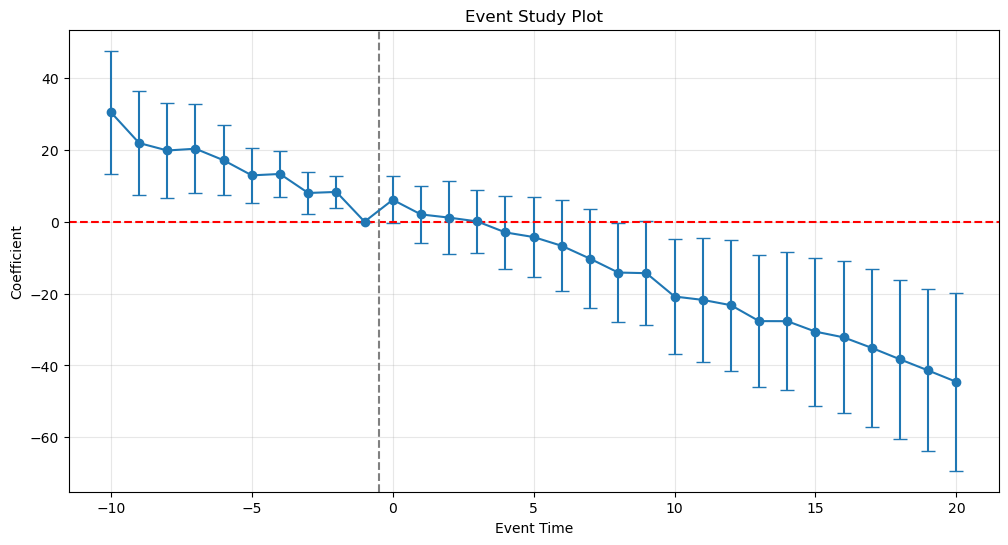

In [17]:
df_es = df[df['rel_time'] != -999].copy()

X_cols = [f'rel_time_{int(rt)}' for rt in rel_times] + ['pcinc', 'asmrh', 'cases']
X = df_es[X_cols].copy()

unit_dummies = pd.get_dummies(df_es['stfips'], prefix='unit', drop_first=True).astype(float)
time_dummies = pd.get_dummies(df_es['year'], prefix='time', drop_first=True).astype(float)

X = pd.concat([X, unit_dummies, time_dummies], axis=1)

y = df_es['asmrs'].values
X_array = X.values

model_es = OLS(y, X_array)
result_es = model_es.fit(cov_type='cluster', cov_kwds={'groups': df_es['stfips'].values})

coefs = []
ses = []
for i, rt in enumerate(rel_times):
    coefs.append(result_es.params[i])
    ses.append(result_es.bse[i])

rel_times_with_baseline = sorted(rel_times + [-1])
coefs_with_baseline = []
ses_with_baseline = []
for rt in rel_times_with_baseline:
    if rt == -1:
        coefs_with_baseline.append(0)
        ses_with_baseline.append(0)
    else:
        idx = rel_times.index(rt)
        coefs_with_baseline.append(coefs[idx])
        ses_with_baseline.append(ses[idx])

plt.figure(figsize=(12, 6))
plt.errorbar(rel_times_with_baseline, coefs_with_baseline, 
             yerr=1.96*np.array(ses_with_baseline), 
             fmt='o-', capsize=5)
plt.axhline(y=0, color='r', linestyle='--')
plt.axvline(x=-0.5, color='gray', linestyle='--')
plt.xlabel('Event Time')
plt.ylabel('Coefficient')
plt.title('Event Study Plot')
plt.grid(True, alpha=0.3)
plt.show()

# Question 2 — CSDiD

# a)

In [27]:
try:
    from csdid.att_gt import attgt
    from csdid.att_gt import aggte
    
    df_csdid = df[df['_nfd'].notna()].copy()
    df_csdid['treat_year'] = df_csdid['_nfd'].astype(int)
    
    result_attgt = attgt(
        df_csdid,
        yname='asmrs',
        gname='treat_year',
        tname='year',
        idname='stfips',
        xformla='~ pcinc + asmrh + cases'
    )
print(result_attgt)


SyntaxError: expected 'except' or 'finally' block (286112177.py, line 16)

# b)

In [21]:
 from csdid.att_gt import aggte
    
    agg_group = aggte(result_attgt, type='group')
    print("\nAggregation by Group:")
    print(agg_group)
    
    agg_time = aggte(result_attgt, type='calendar')
    print("\nAggregation by Period:")
    print(agg_time)
    
    agg_event = aggte(result_attgt, type='dynamic')
    print("\nAggregation by Event-Time:")
    print(agg_event)
    
except ImportError as e:
    print("\n" + "="*50)
    print("Question 2: CSDiD - Package not installed correctly")
    print("="*50)
    print(f"Error: {e}")
    print("Install using: pip install csdid")
except Exception as e:
    print(f"\nError in CSDiD estimation: {str(e)}")

IndentationError: unexpected indent (1576489203.py, line 3)

# c)

# d)